# Drug Side Effects - Pipeline de 3 Agentes con LangChain + Mistral AI

Pipeline completo de 3 agentes especializados:

| Agente | Funcion |
|--------|--------|
| Agente 1 - Normalizador | Limpia, imputa, escala y codifica el dataset |
| Agente 2 - Entrenador | Entrena modelos con validacion, selecciona metricas y el mejor modelo |
| Agente 3 - Comunicador | Genera un reporte en lenguaje natural con los resultados |

Modelo: mistral-small-latest via LangChain  
Dataset: Drug Side Effects (100k registros)

## PASO 1 - Instalacion de dependencias

In [4]:
%%capture
%pip install numpy scikit-learn pandas openpyxl tabulate --quiet
%pip install langchain langchain-mistralai langchain-experimental --quiet

print('Instalacion completada')

## PASO 2 - Configurar API Key de Mistral AI

In [5]:
import os
from getpass import getpass

MIAPIKEI = getpass('Ingresa tu Mistral API Key: ')
os.environ['MIAPIKEI'] = MIAPIKEI

print(f'API Key configurada ({len(MIAPIKEI)} chars)')

API Key configurada (32 chars)


## PASO 3 - Inicializar el modelo Mistral

In [6]:
from langchain_mistralai import ChatMistralAI
import time
import httpx
import warnings
warnings.filterwarnings('ignore')

llm = ChatMistralAI(
    model='mistral-small-latest',
    temperature=0,
    api_key=MIAPIKEI
)

for intento in range(3):
    try:
        resp = llm.invoke('Decime Listo para procesar datos en espanol.')
        print(f'Mistral: {resp.content}')
        break
    except httpx.HTTPStatusError as e:
        if e.response.status_code == 429:
            espera = 10 * (2 ** intento)
            print(f'Rate limit. Esperando {espera}s...')
            time.sleep(espera)
        else:
            raise

Mistral: ¡Listo! Estoy preparado para procesar datos en español. Puedes enviarme información, preguntas o solicitudes relacionadas con datos, análisis, procesamiento de texto, traducción, o cualquier otra tarea en español, y te ayudaré con gusto.

¿En qué puedo asistirte hoy? 😊


## PASO 4 - Cargar el Dataset de Efectos Secundarios

In [7]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv('drug_side_effects_100k_dataset.csv')

print(f'Dataset: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head()

Dataset: 100000 filas x 16 columnas
Columnas: ['patient_id', 'age', 'gender', 'country', 'drug_name', 'dosage_mg', 'side_effect', 'severity', 'outcome', 'report_date', 'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized', 'recovery_days']


,patient_id,age,gender,country,drug_name,dosage_mg,side_effect,severity,outcome,report_date,treatment_start_date,chronic_condition,smoker,alcohol_use,hospitalized,recovery_days
0,PT-100000,56,Female,USA,Atorvastatin,25,Muscle Pain,Moderate,Recovering,2021-12-08,2021-11-23,Hypertension,Yes,Frequent,No,36.0
1,PT-100001,45,Male,USA,Sertraline,5,Dry Mouth,Mild,Recovered,2023-02-10,2023-02-04,Hypertension,Yes,Frequent,No,40.0
2,PT-100002,76,Female,Pakistan,Insulin,25,Hypoglycemia,Mild,Recovering,2021-07-30,2021-07-01,Heart Disease,No,NaN,No,12.0
3,PT-100003,61,Female,USA,Paracetamol,20,Rash,Moderate,Recovered,2025-05-02,2025-04-18,Asthma,Yes,NaN,No,26.0
4,PT-100004,39,Female,India,Amlodipine,5,Dizziness,Mild,Recovered,2025-05-23,2025-04-06,NaN,Yes,Occasional,No,7.0


## PASO 5 - Exploracion rapida del Dataset

In [8]:
print('='*60)
print('INFO DEL DATASET')
print('='*60)

info_df = pd.DataFrame({
    'Dtype':       df_raw.dtypes,
    'Nulos':       df_raw.isnull().sum(),
    '% Nulos':     (df_raw.isnull().mean() * 100).round(2),
    'Unicos':      df_raw.nunique()
})
display(info_df)

print()
print('='*60)
print('ESTADISTICAS NUMERICAS')
print('='*60)
display(df_raw.describe(include='all').T)

INFO DEL DATASET


,Dtype,Nulos,% Nulos,Unicos
patient_id,str,0,0.00,100000
age,int64,0,0.00,73
gender,str,0,0.00,2
country,str,0,0.00,7
drug_name,str,0,0.00,10
dosage_mg,int64,0,0.00,8
side_effect,str,0,0.00,21
severity,str,0,0.00,3
outcome,str,0,0.00,4
report_date,str,0,0.00,1884



ESTADISTICAS NUMERICAS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,100000,100000,PT-100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,47.78174,17.055106,18.0,35.0,47.0,60.0,90.0
gender,100000,2,Male,50059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,100000,7,UK,14451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drug_name,100000,10,Amoxicillin,10148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dosage_mg,100000.0,NaN,NaN,NaN,119.89625,162.249791,5.0,10.0,25.0,250.0,500.0
side_effect,100000,21,Nausea,13373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,100000,3,Mild,61969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outcome,100000,4,Recovered,69165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_date,100000,1884,2026-04-18,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Funcion helper - llamada segura con reintentos

In [9]:
def invoke_with_retry(agent, prompt, max_retries=6, base_wait=10):
    for intento in range(max_retries):
        try:
            return agent.invoke({'input': prompt})
        except httpx.HTTPStatusError as e:
            if e.response.status_code == 429:
                espera = base_wait * (2 ** intento)
                print(f'Rate limit ({intento+1}/{max_retries}). Esperando {espera}s...')
                time.sleep(espera)
            else:
                raise
    raise Exception('Se agotaron los reintentos por rate limit')

print('Helper listo')

Helper listo


---
## AGENTE 1 - Normalizador

Objetivo: Limpiar, imputar valores faltantes, escalar numericas y codificar categoricas.

Usa create_pandas_dataframe_agent con instrucciones para evitar errores de pandas.

In [10]:
from langchain_experimental.agents import create_pandas_dataframe_agent

agent_normalizador = create_pandas_dataframe_agent(
    llm                  = llm,
    df                   = df_raw,
    agent_type           = 'tool-calling',
    verbose              = True,
    allow_dangerous_code = True,
    prefix               = '''
Eres un experto en limpieza y preprocesamiento de datos con pandas.

REGLAS CRITICAS (NO USAR INPLACE):
- NUNCA uses inplace=True. Siempre asignacion directa.
- MAL: df['col'].fillna(valor, inplace=True)
- BIEN: df['col'] = df['col'].fillna(valor)
- MAL: df.drop(columns=['x'], inplace=True)
- BIEN: df = df.drop(columns=['x'])

Trabajas con un DataFrame 'df' de efectos secundarios de medicamentos.
Siempre hace una copia al inicio: df_limpio = df.copy()
Al final de cada paso, muestra un resumen de lo que cambio.
Al finalizar todo, la variable df_limpio debe estar disponible.
IMPORTANTE: La columna 'severity' debe quedar como texto original sin codificar.
'''
)

print('Agente Normalizador creado')

Agente Normalizador creado


In [11]:
def ejecutar_normalizacion():
    prompt_unico = '''
    Ejecuta en orden los siguientes pasos sobre df_limpio (copia de df):

    PASO 1:
    Hace df_limpio = df.copy().
    Muestra cuantas filas y columnas tiene.

    PASO 2:
    Analiza los valores nulos en df_limpio.
    Para numericas con nulos: df_limpio['col'] = df_limpio['col'].fillna(mediana).
    Para categoricas con nulos: df_limpio['col'] = df_limpio['col'].fillna(moda).
    Muestra nulos antes y despues.

    PASO 3:
    Identifica las columnas categoricas (tipo 'object') en df_limpio.
    Excluye 'severity', 'patient_id', 'report_date', 'treatment_start_date'.
    Aplica pd.get_dummies() a las categoricas con menos de 10 valores unicos.
    Al resto, aplica Label Encoding con df['col'] = df['col'].astype('category').cat.codes.
    Muestra cuantas columnas habia antes y despues.

    PASO 4:
    Identifica las columnas numericas en df_limpio.
    Excluye 'patient_id' si existe.
    Aplica StandardScaler:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    cols_num = [lista de columnas numericas]
    df_limpio[cols_num] = scaler.fit_transform(df_limpio[cols_num])
    Muestra medias y desvios antes/despues.

    PASO 5:
    Informa el estado final de df_limpio:
    - Dimensiones
    - Columnas numericas vs categoricas
    - Verifica que no haya nulos
    - Muestra las primeras 3 filas

    PASO FINAL:
    Guarda df_limpio a CSV con: df_limpio.to_csv('df_limpio.csv', index=False)
    Confirma que el archivo se guardo correctamente.
    '''

    print()
    print('='*60)
    print('Ejecutando los 5 pasos en una sola llamada...')
    print('='*60)
    invoke_with_retry(agent_normalizador, prompt_unico)
    print('Normalizacion completada')

ejecutar_normalizacion()


Ejecutando los 5 pasos en una sola llamada...


> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'import pandas as pd\nfrom sklearn.preprocessing import StandardScaler\n\n# PASO 1: Copia del DataFrame y mostrar dimensiones iniciales\ndf_limpio = df.copy()\nprint("Dimensiones iniciales del DataFrame:")\nprint(f"Filas: {df_limpio.shape[0]}, Columnas: {df_limpio.shape[1]}")'}`


Dimensiones iniciales del DataFrame:
Filas: 100000, Columnas: 16

Invoking: `python_repl_ast` with `{'query': '# PASO 2: Analizar y manejar valores nulos\nprint("Valores nulos antes de limpieza:")\nprint(df_limpio.isnull().sum())\n\n# Columnas numéricas con nulos\ncols_numericas = df_limpio.select_dtypes(include=[\'int64\', \'float64\']).columns\nfor col in cols_numericas:\n    if df_limpio[col].isnull().sum() > 0:\n        mediana = df_limpio[col].median()\n        df_limpio[col] = df_limpio[col].fillna(mediana)\n\n# Columnas categóricas con nulos\ncols_categoricas = df_limpio.s

In [12]:
if os.path.exists('df_limpio.csv'):
    df_limpio = pd.read_csv('df_limpio.csv')
    print(f'df_limpio cargado: {df_limpio.shape}, nulos: {df_limpio.isnull().sum().sum()}')
    display(df_limpio.head())
else:
    print('df_limpio.csv no encontrado. Ejecuta la celda de normalizacion primero.')

df_limpio cargado: (100000, 26), nulos: 0


,patient_id,age,drug_name,dosage_mg,side_effect,severity,report_date,treatment_start_date,recovery_days,gender_Male,country_Canada,country_Germany,country_India,country_Pakistan,country_UK,country_USA,outcome_Hospitalized,outcome_Recovered,outcome_Recovering,chronic_condition_Diabetes,chronic_condition_Heart Disease,chronic_condition_Hypertension,chronic_condition_Kidney Disease,smoker_Yes,alcohol_use_Occasional,hospitalized_Yes
0,PT-100000,0.481867,2,-0.584880,13,Moderate,2021-12-08,2021-11-23,1.038300,False,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False,False
1,PT-100001,-0.163104,9,-0.708148,6,Mild,2023-02-10,2023-02-04,1.373789,True,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False
2,PT-100002,1.654543,4,-0.584880,10,Mild,2021-07-30,2021-07-01,-0.974636,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False
3,PT-100003,0.775036,8,-0.615697,16,Moderate,2025-05-02,2025-04-18,0.199577,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False
4,PT-100004,-0.514906,0,-0.708148,4,Mild,2025-05-23,2025-04-06,-1.393997,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,True,False


---
## AGENTE 2 - Entrenador

Objetivo: Entrenar modelos de clasificacion, validar con cross-validation, seleccionar metricas y elegir el mejor modelo.

Usa LangChain agent + scikit-learn. Target: severity (Mild, Moderate, Severe).

In [24]:
if os.path.exists('df_limpio.csv'):
    df_limpio = pd.read_csv('df_limpio.csv')
    df_ml = df_limpio.copy()
    print(f'df_limpio cargado: {df_ml.shape}')
else:
    df_ml = df_raw.copy()
    print('Usando df_raw (df_limpio.csv no encontrado)')

target_col = 'severity'

if target_col in df_ml.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df_ml[target_col] = le.fit_transform(df_ml[target_col].astype(str))
    print(f'Target codificado: {dict(enumerate(le.classes_))}')

    exclude_cols = [target_col, 'patient_id', 'report_date', 'treatment_start_date']
    feature_cols = [c for c in df_ml.columns if c not in exclude_cols]

    for col in df_ml[feature_cols].select_dtypes(include=['object', 'category']).columns:
        df_ml[col] = LabelEncoder().fit_transform(df_ml[col].astype(str))

    print(f'Features: {len(feature_cols)} columnas numericas')
    print(f'Target: {df_ml[target_col].nunique()} clases')
else:
    print(f'Columna {target_col} no encontrada')

df_limpio cargado: (100000, 26)
Target codificado: {0: 'Mild', 1: 'Moderate', 2: 'Severe'}
Features: 22 columnas numericas
Target: 3 clases


### Crear Agente Entrenador

El agente ejecuta codigo Python via sklearn y guarda los resultados en variables globales que persisten fuera del agente.

In [25]:
agent_entrenador = create_pandas_dataframe_agent(
    llm                  = llm,
    df                   = df_ml,
    agent_type           = 'tool-calling',
    verbose              = True,
    allow_dangerous_code = True,
    prefix               = '''
Eres un experto en Machine Learning. La variable target es 'severity'.

IMPORTANTE: usa from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
usa from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
usa from sklearn.linear_model import LogisticRegression
usa from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
usa from sklearn.preprocessing import LabelEncoder

SIEMPRE usa train_test_split con stratify, 5-fold cross-validation.

ALMACENA resultados en 'resultados_modelos' como lista de diccionarios.
CADA diccionario debe tener: 'modelo', 'cv_accuracy', 'cv_f1', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1'

Elige el mejor modelo por f1-score macro y guardalo como string en 'mejor_modelo'.

REGLAS:
- NO uses inplace=True
- Si un modelo da error, prueba el siguiente
- Muestra matriz de confusion del mejor modelo
CUANDO termines todos los pasos, imprime 'ENTRENAMIENTO FINALIZADO'
'''
)

print('Agente Entrenador creado')

Agente Entrenador creado


In [ ]:
def ejecutar_entrenamiento():
    prompt_unico = '''
    Ejecuta en orden los siguientes pasos:

    PASO 1:
    Divide los datos:
    X = todas las columnas excepto severity, patient_id, report_date, treatment_start_date
    y = columna severity
    train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    Muestra cuantas muestras en train y test.

    PASO 2:
    Entrena LogisticRegression(max_iter=1000).
    Evaluacion cruzada: cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1_macro')
    Evaluacion en test: accuracy, precision, recall, f1.
    Guarda en resultados_modelos.

    PASO 3:
    Entrena RandomForestClassifier(n_estimators=100, random_state=42).
    Evaluacion cruzada y en test.
    Guarda en resultados_modelos.

    PASO 4:
    Entrena GradientBoostingClassifier(n_estimators=100, random_state=42).
    Evaluacion cruzada y en test.
    Guarda en resultados_modelos.

    PASO 5:
    Compara todos los modelos en resultados_modelos.
    Muestra una tabla con accuracy, precision, recall, f1 de cada uno.
    Elige el mejor por f1-score macro.
    Guarda su nombre como string en 'mejor_modelo'.
    Muestra la matriz de confusion del mejor modelo.
    Imprime ENTRENAMIENTO FINALIZADO al terminar.

    PASO FINAL:
    Importa json y guarda resultados_modelos y mejor_modelo a archivos:
    with open('resultados_modelos.json', 'w') as f:
        json.dump(resultados_modelos, f)
    with open('mejor_modelo.txt', 'w') as f:
        f.write(mejor_modelo)
    Confirma que los archivos se guardaron.
    '''

    print()
    print('='*60)
    print('Ejecutando entrenamiento en una sola llamada...')
    print('='*60)
    invoke_with_retry(agent_entrenador, prompt_unico)
    print('Entrenamiento completado')

ejecutar_entrenamiento()


Ejecutando entrenamiento en una sola llamada...


> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'import pandas as pd\nfrom sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold\nfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix\nfrom sklearn.preprocessing import LabelEncoder\nimport json\n\n# Cargar los datos (asumiendo que ya están cargados en df)\n# Si no, se cargarían aquí. Por ejemplo:\n# df = pd.read_csv(\'nombre_del_archivo.csv\')\n\n# PASO 1: Dividir los datos\nX = df.drop(columns=[\'severity\', \'patient_id\', \'report_date\', \'treatment_start_date\'])\ny = df[\'severity\']\n\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)\n\nprint(f"Número de muestras 

In [16]:
import json

if os.path.exists('resultados_modelos.json'):
    with open('resultados_modelos.json') as f:
        resultados_modelos = json.load(f)
    print('='*60)
    print('RESULTADOS DE MODELOS')
    print('='*60)
    display(pd.DataFrame(resultados_modelos))
else:
    print('resultados_modelos.json no encontrado')
    resultados_modelos = []

if os.path.exists('mejor_modelo.txt'):
    with open('mejor_modelo.txt') as f:
        mejor_modelo = f.read().strip()
    print(f'Mejor modelo: {mejor_modelo}')
else:
    print('mejor_modelo.txt no encontrado')
    mejor_modelo = ''

RESULTADOS DE MODELOS


,modelo,cv_accuracy,cv_f1,test_accuracy,test_precision,test_recall,test_f1
0,LogisticRegression,0.713938,0.513539,0.70845,0.630858,0.502628,0.513333
1,RandomForestClassifier,0.700550,0.518082,0.69540,0.566968,0.500044,0.514949
2,GradientBoostingClassifier,0.713838,0.513216,0.70845,0.630703,0.502778,0.513587


Mejor modelo: RandomForestClassifier


---
## AGENTE 3 - Comunicador

Objetivo: Generar un reporte en lenguaje natural con todos los resultados del pipeline.

Usa Mistral + LangChain con un prompt estructurado.

In [17]:
import json

def construir_contexto_reporte():
    ctx = []

    ctx.append('=== DATASET ORIGINAL ===')
    ctx.append(f'Filas: {df_raw.shape[0]}, Columnas: {df_raw.shape[1]}')
    ctx.append(f'Columnas: {list(df_raw.columns)}')
    ctx.append(f'Nulos originales: {df_raw.isnull().sum().sum()}')

    ctx.append('')
    ctx.append('=== DATASET NORMALIZADO ===')
    if os.path.exists('df_limpio.csv'):
        df_local = pd.read_csv('df_limpio.csv')
        ctx.append(f'Filas: {df_local.shape[0]}, Columnas: {df_local.shape[1]}')
        ctx.append(f'Nulos despues: {df_local.isnull().sum().sum()}')
    else:
        ctx.append('No disponible')

    ctx.append('')
    ctx.append('=== RESULTADOS DE MODELOS ===')
    if os.path.exists('resultados_modelos.json'):
        with open('resultados_modelos.json') as f:
            res_local = json.load(f)
        for m in res_local:
            if isinstance(m, dict):
                ctx.append(f"- {str(m.get('modelo', '?')):20} | "
                    f"Acc={m.get('test_accuracy', 0):.4f} | "
                    f"Prec={m.get('test_precision', 0):.4f} | "
                    f"Rec={m.get('test_recall', 0):.4f} | "
                    f"F1={m.get('test_f1', 0):.4f}")
            else:
                ctx.append(f"- {m}")
    else:
        ctx.append('No disponibles')

    ctx.append('')
    ctx.append('=== MEJOR MODELO ===')
    if os.path.exists('mejor_modelo.txt'):
        with open('mejor_modelo.txt') as f:
            ctx.append(f.read().strip())
    else:
        ctx.append('No seleccionado')

    return '\n'.join(ctx)

contexto = construir_contexto_reporte()
print(contexto)

=== DATASET ORIGINAL ===
Filas: 100000, Columnas: 16
Columnas: ['patient_id', 'age', 'gender', 'country', 'drug_name', 'dosage_mg', 'side_effect', 'severity', 'outcome', 'report_date', 'treatment_start_date', 'chronic_condition', 'smoker', 'alcohol_use', 'hospitalized', 'recovery_days']
Nulos originales: 61846

=== DATASET NORMALIZADO ===
Filas: 100000, Columnas: 26
Nulos despues: 0

=== RESULTADOS DE MODELOS ===
- LogisticRegression   | Acc=0.7085 | Prec=0.6309 | Rec=0.5026 | F1=0.5133
- RandomForestClassifier | Acc=0.6954 | Prec=0.5670 | Rec=0.5000 | F1=0.5149
- GradientBoostingClassifier | Acc=0.7085 | Prec=0.6307 | Rec=0.5028 | F1=0.5136

=== MEJOR MODELO ===
RandomForestClassifier


In [18]:
from langchain_core.prompts import ChatPromptTemplate

prompt_reporte = ChatPromptTemplate.from_messages([
    ('system', '''
Sos un Analista de Datos Senior especializado en farmacovigilancia.
Genera un reporte profesional en markdown con:
1. Resumen Ejecutivo
2. Preprocesamiento: nulos, codificacion, escalado
3. Modelos entrenados y sus metricas (tabla)
4. Modelo seleccionado y justificacion
5. Recomendaciones
Usa numeros concretos, sin placeholders.
Usa el formato markdown de manera profesional.
'''),
    ('user', '{contexto}')
])

for intento in range(3):
    try:
        respuesta = llm.invoke(prompt_reporte.format_messages(contexto=contexto))
        reporte_final = respuesta.content
        break
    except httpx.HTTPStatusError as e:
        if e.response.status_code == 429:
            espera = 15 * (2 ** intento)
            print(f'Rate limit. Esperando {espera}s...')
            time.sleep(espera)
        else:
            raise

print('='*60)
print('REPORTE GENERADO')
print('='*60)
print(reporte_final)

REPORTE GENERADO
```markdown
# **Reporte de Análisis de Farmacovigilancia**
**Fecha:** 2024-05-XX
**Analista:** [Nombre del Analista]
**Objetivo:** Predecir la severidad de reacciones adversas a medicamentos (RAM) en pacientes.

---

## **1. Resumen Ejecutivo**
Se analizó un dataset de **100,000 registros** con **16 variables originales** (61,846 valores nulos) que, tras preprocesamiento, se expandió a **26 columnas** sin valores faltantes. El objetivo fue predecir la **severidad** de las reacciones adversas a medicamentos (RAM) utilizando modelos de clasificación.

**Hallazgos clave:**
- El **RandomForestClassifier** fue seleccionado como mejor modelo, con un **F1-score de 0.5149** y precisión de **0.5670**.
- Los modelos evaluados (Logistic Regression, Random Forest y Gradient Boosting) mostraron un rendimiento similar, pero Random Forest destacó por su equilibrio entre métricas.
- La normalización del dataset eliminó todos los valores nulos, mejorando la calidad de los datos.

---



In [19]:
with open('reporte_efectos_secundarios.md', 'w', encoding='utf-8') as f:
    f.write(reporte_final)

print(f'Reporte guardado: reporte_efectos_secundarios.md')
print(f'Total: {len(reporte_final)} caracteres')

Reporte guardado: reporte_efectos_secundarios.md
Total: 6945 caracteres


---
## Pipeline completo

Ejecuta todo en secuencia.

In [20]:
print('INICIANDO PIPELINE COMPLETO')

# --- AGENTE 1 ---
print('='*60)
print('AGENTE 1 - NORMALIZADOR')
print('='*60)
ejecutar_normalizacion()

if os.path.exists('df_limpio.csv'):
    df_limpio = pd.read_csv('df_limpio.csv')
    print(f'df_limpio cargado: {df_limpio.shape}')
else:
    print('ERROR: df_limpio.csv no generado')
    raise FileNotFoundError('df_limpio.csv')

# --- AGENTE 2 ---
print()
print('='*60)
print('AGENTE 2 - ENTRENADOR')
print('='*60)

df_ml = df_limpio.copy()
le = LabelEncoder()
df_ml[target_col] = le.fit_transform(df_ml[target_col].astype(str))
exclude_cols = [target_col, 'patient_id', 'report_date', 'treatment_start_date']
feature_cols = [c for c in df_ml.columns if c not in exclude_cols]
for col in df_ml[feature_cols].select_dtypes(include=['object', 'category']).columns:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col].astype(str))

agent_entrenador = create_pandas_dataframe_agent(
    llm=llm, df=df_ml, agent_type='tool-calling',
    verbose=True, allow_dangerous_code=True,
    prefix='Eres un experto en ML. Target: severity. No uses inplace=True.'
)
ejecutar_entrenamiento()

import json
if os.path.exists('resultados_modelos.json'):
    with open('resultados_modelos.json') as f:
        resultados_modelos = json.load(f)
if os.path.exists('mejor_modelo.txt'):
    with open('mejor_modelo.txt') as f:
        mejor_modelo = f.read().strip()

# --- AGENTE 3 ---
print()
print('='*60)
print('AGENTE 3 - COMUNICADOR')
print('='*60)

contexto = construir_contexto_reporte()
for intento in range(3):
    try:
        respuesta = llm.invoke(prompt_reporte.format_messages(contexto=contexto))
        reporte_final = respuesta.content
        break
    except httpx.HTTPStatusError as e:
        if e.response.status_code == 429:
            time.sleep(15 * (2 ** intento))
        else:
            raise

with open('reporte_efectos_secundarios.md', 'w', encoding='utf-8') as f:
    f.write(reporte_final)

print()
print('='*60)
print('PIPELINE COMPLETADO')
print('='*60)
print()
print('reporte_efectos_secundarios.md generado')
print(reporte_final)

INICIANDO PIPELINE COMPLETO
AGENTE 1 - NORMALIZADOR

Ejecutando los 5 pasos en una sola llamada...


> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'import pandas as pd\nfrom sklearn.preprocessing import StandardScaler\n\n# PASO 1: Copia del DataFrame y mostrar dimensiones\ndf_limpio = df.copy()\nprint("Dimensiones iniciales:")\nprint(f"Filas: {df_limpio.shape[0]}, Columnas: {df_limpio.shape[1]}")'}`


Dimensiones iniciales:
Filas: 100000, Columnas: 16

Invoking: `python_repl_ast` with `{'query': '# PASO 2: Analizar y manejar valores nulos\nprint("\\nValores nulos antes del tratamiento:")\nprint(df_limpio.isnull().sum())\n\n# Columnas numéricas con nulos\ncols_numericas = df_limpio.select_dtypes(include=[\'int64\', \'float64\']).columns\nfor col in cols_numericas:\n    if df_limpio[col].isnull().sum() > 0:\n        mediana = df_limpio[col].median()\n        df_limpio[col] = df_limpio[col].fillna(mediana)\n\n# Columnas categóricas con nulos\ncols_cate

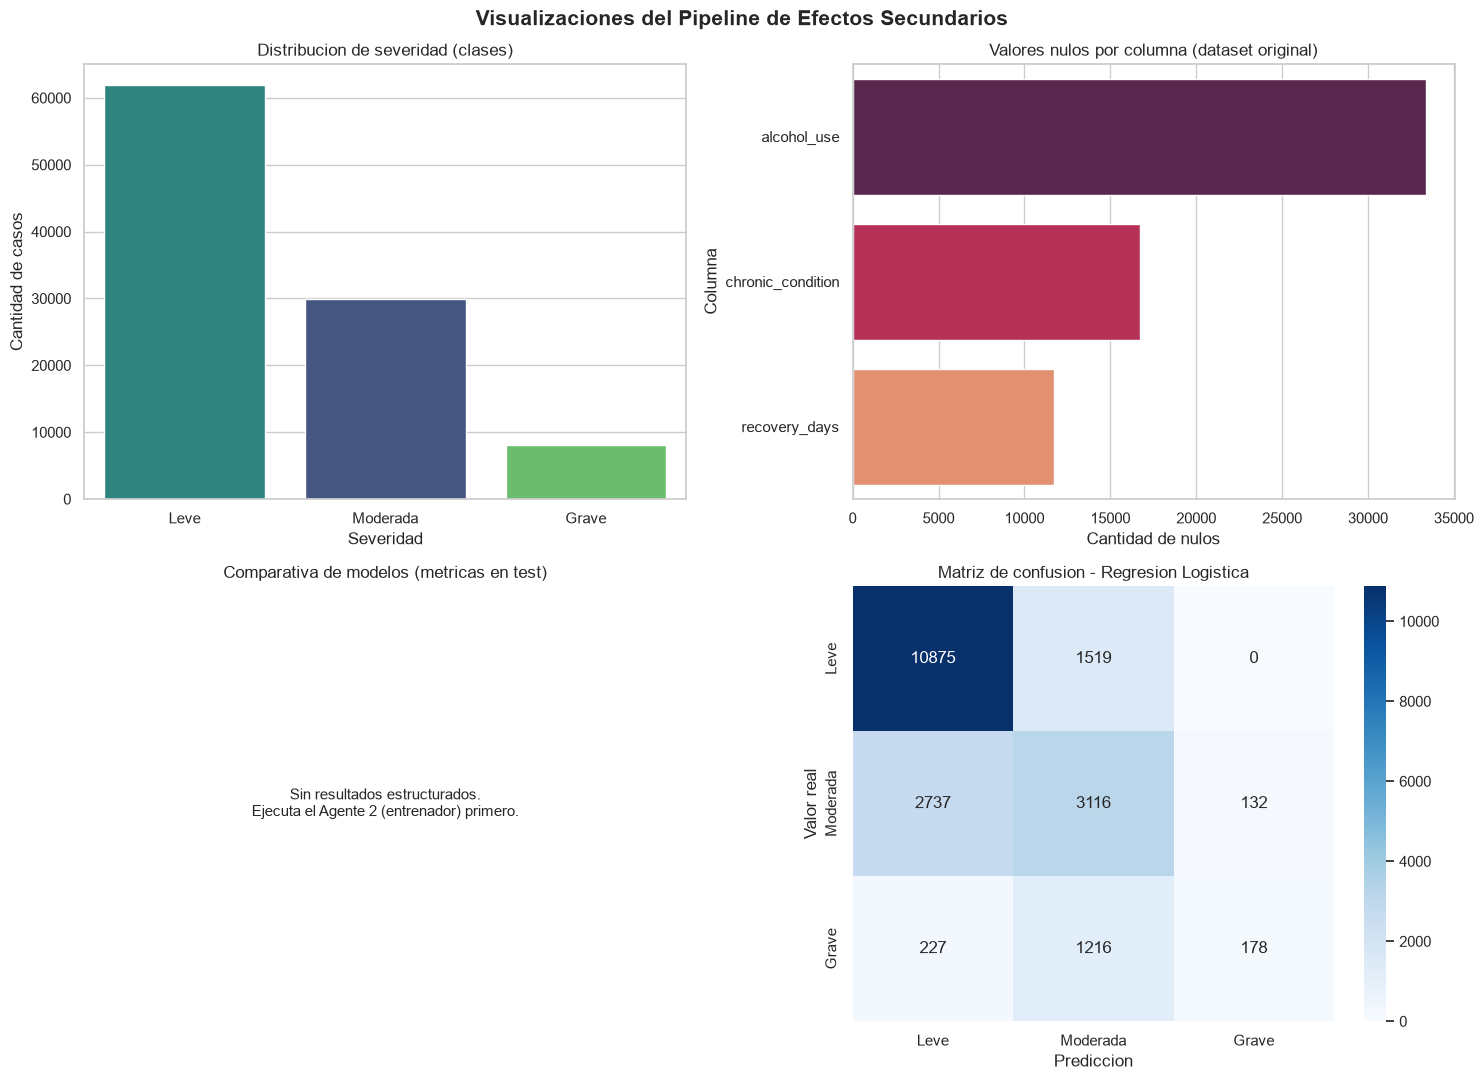

Graficos generados y guardados en graficos_pipeline.png


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

sns.set_theme(style='whitegrid')
df_base = pd.read_csv('drug_side_effects_100k_dataset.csv')

# Nombres en espanol
NOMBRES_MODELO = {
    'LogisticRegression': 'Regresion Logistica',
    'RandomForestClassifier': 'Bosque Aleatorio',
    'GradientBoostingClassifier': 'Gradient Boosting',
}
NOMBRES_METRICA = {
    'test_accuracy': 'Exactitud',
    'test_precision': 'Precision',
    'test_recall': 'Sensibilidad',
    'test_f1': 'Puntaje F1',
}
SEVERIDAD_ES = {'Mild': 'Leve', 'Moderate': 'Moderada', 'Severe': 'Grave'}
orden_es = ['Leve', 'Moderada', 'Grave']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Visualizaciones del Pipeline de Efectos Secundarios', fontsize=15, fontweight='bold')

# 1. Distribucion de la variable objetivo (severidad)
df_sev = df_base.copy()
df_sev['severidad'] = df_sev['severity'].map(SEVERIDAD_ES)
sns.countplot(data=df_sev, x='severidad', order=orden_es, hue='severidad',
              palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribucion de severidad (clases)')
axes[0, 0].set_xlabel('Severidad')
axes[0, 0].set_ylabel('Cantidad de casos')

# 2. Valores nulos por columna
nulos = df_base.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
sns.barplot(x=nulos.values, y=nulos.index, hue=nulos.index,
            palette='rocket', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Valores nulos por columna (dataset original)')
axes[0, 1].set_xlabel('Cantidad de nulos')
axes[0, 1].set_ylabel('Columna')

# 3. Comparativa de metricas de los modelos
res = []
if os.path.exists('resultados_modelos.json'):
    with open('resultados_modelos.json') as f:
        res = [m for m in json.load(f) if isinstance(m, dict)]

if res:
    dfm = pd.DataFrame(res)
    dfm['modelo'] = dfm['modelo'].map(lambda x: NOMBRES_MODELO.get(x, x))
    metr = [c for c in ['test_accuracy', 'test_precision', 'test_recall', 'test_f1'] if c in dfm.columns]
    dfm_long = dfm.melt(id_vars='modelo', value_vars=metr,
                        var_name='metrica', value_name='valor')
    dfm_long['metrica'] = dfm_long['metrica'].map(NOMBRES_METRICA)
    sns.barplot(data=dfm_long, x='modelo', y='valor', hue='metrica',
                palette='mako', ax=axes[1, 0])
    axes[1, 0].set_title('Comparativa de modelos (metricas en test)')
    axes[1, 0].set_xlabel('Modelo')
    axes[1, 0].set_ylabel('Valor')
    axes[1, 0].tick_params(axis='x', rotation=15)
    axes[1, 0].legend(title='Metrica', fontsize=8, loc='lower right')
else:
    axes[1, 0].text(0.5, 0.5,
                    'Sin resultados estructurados.\nEjecuta el Agente 2 (entrenador) primero.',
                    ha='center', va='center', fontsize=11)
    axes[1, 0].set_title('Comparativa de modelos (metricas en test)')
    axes[1, 0].axis('off')

# 4. Matriz de confusion del mejor modelo (se re-entrena sobre df_limpio)
mejor = ''
if os.path.exists('mejor_modelo.txt'):
    with open('mejor_modelo.txt') as f:
        mejor = f.read().strip()

if os.path.exists('df_limpio.csv') and mejor:
    dfl = pd.read_csv('df_limpio.csv')
    dfl['severity'] = LabelEncoder().fit_transform(dfl['severity'].astype(str))
    excl = ['severity', 'patient_id', 'report_date', 'treatment_start_date']
    feats = [c for c in dfl.columns if c not in excl]
    for c in dfl[feats].select_dtypes(include=['object', 'category']).columns:
        dfl[c] = LabelEncoder().fit_transform(dfl[c].astype(str))
    X, y = dfl[feats], dfl['severity']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    modelos = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'RandomForestClassifier': RandomForestClassifier(n_estimators=100, random_state=42),
        'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=100, random_state=42),
    }
    modelo = modelos.get(mejor, RandomForestClassifier(n_estimators=100, random_state=42))
    modelo.fit(Xtr, ytr)
    cm = confusion_matrix(yte, modelo.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=orden_es, yticklabels=orden_es, ax=axes[1, 1])
    axes[1, 1].set_title(f'Matriz de confusion - {NOMBRES_MODELO.get(mejor, mejor)}')
    axes[1, 1].set_xlabel('Prediccion')
    axes[1, 1].set_ylabel('Valor real')
else:
    axes[1, 1].text(0.5, 0.5,
                    'Falta df_limpio.csv o mejor_modelo.txt.\nEjecuta los Agentes 1 y 2 primero.',
                    ha='center', va='center', fontsize=11)
    axes[1, 1].set_title('Matriz de confusion del mejor modelo')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('graficos_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graficos generados y guardados en graficos_pipeline.png')